In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import symengine
from astropy import units as u
from astropy import constants as const
import pandas as pd
from astropy.units import Quantity
from astropy.visualization import quantity_support
from mpl_toolkits.mplot3d import Axes3D 
import mpl_toolkits.mplot3d as m3d
from math import lgamma, log, exp, comb
from SolverFunction import _find_unknown,auto_bracket,solve_quantity
quantity_support()
import sympy as sp
from sympy.solvers import solve
from sympy import symbols, Eq, Function, diff, integrate, simplify, expand, factor

Total possible macrostates: 101
Global method selected: exact
Log-space arithmetic used: True
Cutoff check -> A: term_max=100, log10_max=0.00; B: term_max=100, log10_max=0.00; thresholds: terms<=1200, digits<=250
Macrostate counts are unscaled and stored as log10(multiplicity).
Macrostate (q_A, q_B)=(0, 100): log10(microstates)=9.842030e+03, microstates≈1.071510e9842
Macrostate (q_A, q_B)=(1, 99): log10(microstates)=9.844030e+03, microstates≈1.071510e9844
Macrostate (q_A, q_B)=(2, 98): log10(microstates)=9.845725e+03, microstates≈5.303976e9845
Macrostate (q_A, q_B)=(3, 97): log10(microstates)=9.847239e+03, microstates≈1.732632e9847
Macrostate (q_A, q_B)=(4, 96): log10(microstates)=9.848623e+03, microstates≈4.201633e9848
Macrostate (q_A, q_B)=(5, 95): log10(microstates)=9.849907e+03, microstates≈8.067135e9849
Macrostate (q_A, q_B)=(6, 94): log10(microstates)=9.851106e+03, microstates≈1.277296e9851
Macrostate (q_A, q_B)=(7, 93): log10(microstates)=9.852234e+03, microstates≈1.715227e9852


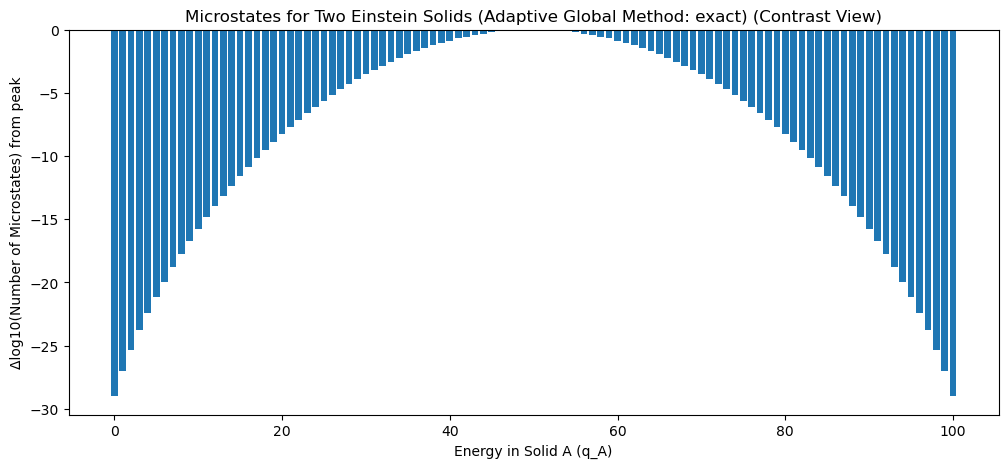

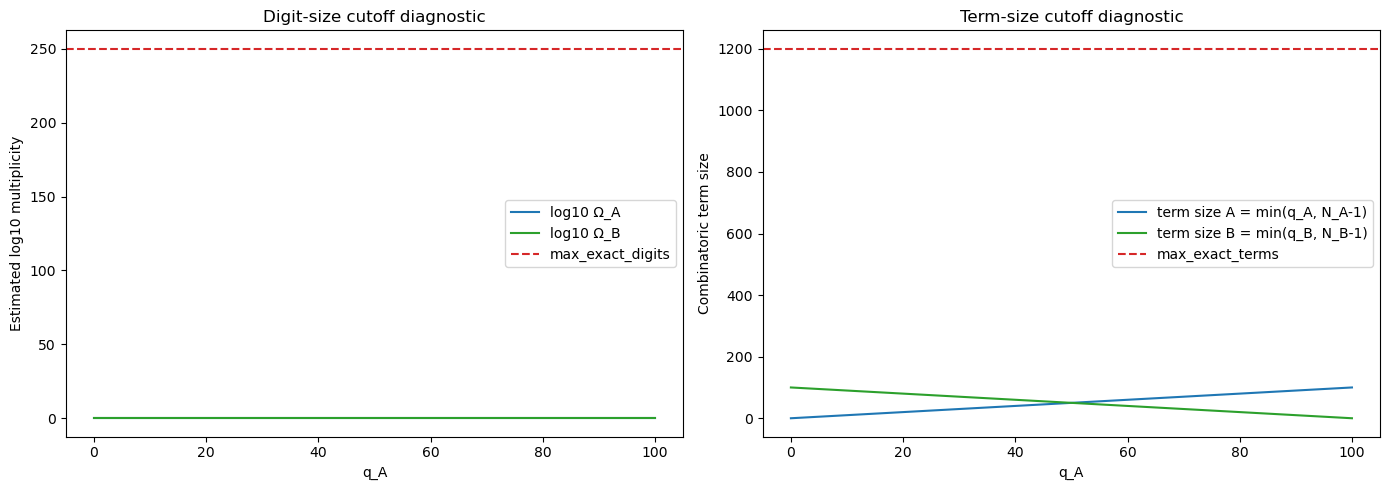

Most likely macrostate: 7.96% of (50, 50) with microstates≈1.081061e9871
Least likely macrostate: 0.00% of (0, 100) with microstates≈1.071510e9842
Probability of most likely macrostate: 0.0796
Probability of least likely macrostate: 0.0000


,q_A,q_B,log10_microstate_count,microstate_count_sci,probability,method,logspace_used
0,0,100,9842.029996,1.071510e9842,7.888609e-31,exact,True
1,1,99,9844.029996,1.071510e9844,7.888609e-29,exact,True
2,2,98,9845.724602,5.303976e9845,3.904861e-27,exact,True
3,3,97,9847.238706,1.732632e9847,1.275588e-25,exact,True
4,4,96,9848.623418,4.201633e9848,3.093301e-24,exact,True
...,...,...,...,...,...,...,...
96,96,4,9848.623418,4.201633e9848,3.093301e-24,exact,True
97,97,3,9847.238706,1.732632e9847,1.275588e-25,exact,True
98,98,2,9845.724602,5.303976e9845,3.904861e-27,exact,True
99,99,1,9844.029996,1.071510e9844,7.888609e-29,exact,True


In [2]:
# Adaptive (non-mixed) multiplicity calculation:
# chooses one global method for the whole run (exact OR Stirling)
# and can automatically switch to log-space arithmetic for huge values.

from math import comb, lgamma, log


def _as_py_int(x):
    """Force Python int arithmetic (avoids NumPy fixed-width integer overflow)."""
    return int(x)


def log_factorial_stirling(n):
    """Stirling approximation for log(n!)."""
    if n < 2:
        return 0.0
    n = float(n)
    return n * log(n) - n + 0.5 * log(2 * np.pi * n)


def multiplicity_stirling_log(N, q):
    """Approximate ln(Omega(N, q)) with Stirling."""
    N_i = _as_py_int(N)
    q_i = _as_py_int(q)
    if N_i <= 0 or q_i < 0:
        return -np.inf
    return (
        log_factorial_stirling(q_i + N_i - 1)
        - log_factorial_stirling(q_i)
        - log_factorial_stirling(N_i - 1)
    )


def multiplicity_stirling(N, q):
    """Approximate multiplicity Omega(N, q) with Stirling."""
    return np.exp(multiplicity_stirling_log(N, q))


def multiplicity_exact_log(N, q):
    """Exact ln(Omega) via log-gamma (good general default)."""
    N_i = _as_py_int(N)
    q_i = _as_py_int(q)
    if N_i <= 0 or q_i < 0:
        return -np.inf
    n = N_i + q_i - 1
    return lgamma(float(n) + 1.0) - lgamma(float(q_i) + 1.0) - lgamma(float(N_i))


def multiplicity_exact(N, q):
    """Exact multiplicity using combinatorics."""
    N_i = _as_py_int(N)
    q_i = _as_py_int(q)
    if N_i <= 0 or q_i < 0:
        return 0
    return comb(q_i + N_i - 1, q_i)


def build_log_omegas_exact_recurrence(N, q_max):
    """Build ln(Omega(N, q)) for q=0..q_max using a stable recurrence."""
    N_i = _as_py_int(N)
    q_max_i = _as_py_int(q_max)
    if N_i <= 0 or q_max_i < 0:
        return np.full(q_max_i + 1, -np.inf)

    log_omegas = np.zeros(q_max_i + 1, dtype=float)  # log Omega(q=0)=0
    for q in range(q_max_i):
        log_omegas[q + 1] = log_omegas[q] + log(float(N_i + q)) - log(float(q + 1))
    return log_omegas


def estimated_log10_multiplicity(N, q):
    """Estimate log10(Omega) using log-gamma for stable cutoff checks."""
    if int(N) <= 0 or int(q) < 0:
        return -np.inf
    return multiplicity_exact_log(N, q) / np.log(10)


def choose_global_method(N_A, N_B, q_total, max_exact_terms=1200, max_exact_digits=250):
    """
    Pick one method for all macrostates.

    If worst-case term size and worst-case estimated digits for BOTH solids
    stay under thresholds, use exact globally; otherwise use Stirling globally.
    """
    term_A_max = min(q_total, N_A - 1)
    term_B_max = min(q_total, N_B - 1)

    log10_A_max = estimated_log10_multiplicity(N_A, q_total)
    log10_B_max = estimated_log10_multiplicity(N_B, q_total)

    use_exact = (
        term_A_max <= max_exact_terms
        and term_B_max <= max_exact_terms
        and log10_A_max <= max_exact_digits
        and log10_B_max <= max_exact_digits
    )

    diagnostics = {
        'term_A_max': term_A_max,
        'term_B_max': term_B_max,
        'log10_A_max': log10_A_max,
        'log10_B_max': log10_B_max,
        'max_exact_terms': max_exact_terms,
        'max_exact_digits': max_exact_digits,
    }

    return ('exact' if use_exact else 'stirling'), diagnostics


def choose_logspace_mode(
    N_A,
    N_B,
    q_total,
    max_standard_N=10**9,
    max_standard_q=5000,
    max_standard_log10=250,
):
    """
    Decide whether to compute macrostates in log-space to avoid overflow.
    """
    log10_A_max = estimated_log10_multiplicity(N_A, q_total)
    log10_B_max = estimated_log10_multiplicity(N_B, q_total)

    use_logspace = (
        N_A > max_standard_N
        or N_B > max_standard_N
        or q_total > max_standard_q
        or log10_A_max > max_standard_log10
        or log10_B_max > max_standard_log10
    )

    diagnostics = {
        'max_standard_N': max_standard_N,
        'max_standard_q': max_standard_q,
        'max_standard_log10': max_standard_log10,
        'use_logspace': use_logspace,
    }

    return use_logspace, diagnostics


def log10_to_sci(log10_value):
    """Convert log10(x) to readable scientific notation string."""
    if not np.isfinite(log10_value):
        return "0"
    exponent = int(np.floor(log10_value))
    mantissa = 10 ** (log10_value - exponent)
    return f"{mantissa:.6f}e{exponent}"


def log10sumexp(log10_values):
    """Stable log10(sum(10**v_i)) for a list/array of log10 values."""
    max_log10 = np.max(log10_values)
    return max_log10 + np.log10(np.sum(10 ** (log10_values - max_log10)))


def find_all_microstates_two_einstein_solids(
    N_A,
    N_B,
    q_total,
    max_exact_terms=1200,
    max_exact_digits=250,
    max_standard_N=10**9,
    max_standard_q=5000,
    max_standard_log10=250,
):
    """
    Returns macrostate multiplicities for two Einstein solids,
    using one globally-selected adaptive method and optional log-space arithmetic.

    - If not in log-space mode: returns raw multiplicity values.
    - If in log-space mode: returns absolute multiplicities as log10 values.
    """
    method, diagnostics = choose_global_method(
        N_A,
        N_B,
        q_total,
        max_exact_terms=max_exact_terms,
        max_exact_digits=max_exact_digits,
    )

    use_logspace, logspace_diag = choose_logspace_mode(
        N_A,
        N_B,
        q_total,
        max_standard_N=max_standard_N,
        max_standard_q=max_standard_q,
        max_standard_log10=max_standard_log10,
    )

    diagnostics.update(logspace_diag)

    if use_logspace:
        # Stable for very large N with modest q_total.
        log_omega_A = build_log_omegas_exact_recurrence(N_A, q_total)
        log_omega_B = build_log_omegas_exact_recurrence(N_B, q_total)

        macrostate_multiplicity = {
            (q_A, q_total - q_A): (log_omega_A[q_A] + log_omega_B[q_total - q_A]) / np.log(10)
            for q_A in range(q_total + 1)
        }

        diagnostics['counts_are_log10'] = True
        diagnostics['counts_are_scaled'] = False
        diagnostics['logspace_kernel'] = 'exact_recurrence'
    else:
        macrostate_multiplicity = {}

        for q_A in range(q_total + 1):
            q_B = q_total - q_A

            if method == 'exact':
                omega_A = multiplicity_exact(N_A, q_A)
                omega_B = multiplicity_exact(N_B, q_B)
            else:
                omega_A = multiplicity_stirling(N_A, q_A)
                omega_B = multiplicity_stirling(N_B, q_B)

            macrostate_multiplicity[(q_A, q_B)] = float(omega_A) * float(omega_B)

        diagnostics['counts_are_log10'] = False
        diagnostics['counts_are_scaled'] = False

    return macrostate_multiplicity, method, use_logspace, diagnostics


# Example usage
NA = 10**100
NB = 10**100
Q_total = 100

microstates_dict, method_used, logspace_used, method_diag = find_all_microstates_two_einstein_solids(NA, NB, Q_total)

print(f"Total possible macrostates: {len(microstates_dict)}")
print(f"Global method selected: {method_used}")
print(f"Log-space arithmetic used: {logspace_used}")
print(
    f"Cutoff check -> "
    f"A: term_max={method_diag['term_A_max']}, log10_max={method_diag['log10_A_max']:.2f}; "
    f"B: term_max={method_diag['term_B_max']}, log10_max={method_diag['log10_B_max']:.2f}; "
    f"thresholds: terms<={method_diag['max_exact_terms']}, digits<={method_diag['max_exact_digits']}"
)

if method_diag['counts_are_log10']:
    print("Macrostate counts are unscaled and stored as log10(multiplicity).")

if method_diag['counts_are_log10']:
    log10_values = np.array(list(microstates_dict.values()))
    total_log10_microstates = log10sumexp(log10_values)
else:
    total_microstates_count = sum(microstates_dict.values())

for macrostate, count in microstates_dict.items():
    if method_diag['counts_are_log10']:
        print(f"Macrostate (q_A, q_B)={macrostate}: log10(microstates)={count:.6e}, microstates≈{log10_to_sci(count)}")
    else:
        print(f"Macrostate (q_A, q_B)={macrostate}: {count:.3e} microstates")

if method_diag['counts_are_log10']:
    print(f"Total microstates: log10(total)={total_log10_microstates:.6e}, total≈{log10_to_sci(total_log10_microstates)}")
else:
    print(f"Total number of all microstates: {total_microstates_count:.3e}")

x = []
y = []
for macrostate, count in microstates_dict.items():
    q_A, _ = macrostate
    x.append(q_A)
    y.append(count)

if method_diag['counts_are_log10']:
    y_plot = np.array(y) - np.max(y)
    y_label = 'Δlog10(Number of Microstates) from peak'
    title_suffix = ' (Contrast View)'
else:
    y_plot = y
    y_label = 'Number of Microstates'
    title_suffix = ''

# Plot distribution
plt.figure(figsize=(12, 5))
plt.bar(x, y_plot, color='tab:blue' if method_used == 'exact' else 'tab:orange')
plt.xlabel('Energy in Solid A (q_A)')
plt.ylabel(y_label)
plt.title(f"Microstates for Two Einstein Solids (Adaptive Global Method: {method_used}){title_suffix}")
plt.show()

# Cutoff diagnostics (global decision view)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

q_scan = list(range(Q_total + 1))
q_vals = np.array(q_scan, dtype=float)
log10_A_curve = np.array([estimated_log10_multiplicity(NA, q) for q in q_scan])
log10_B_curve = np.array([estimated_log10_multiplicity(NB, Q_total - q) for q in q_scan])

if NA - 1 >= Q_total:
    term_A_curve = q_vals.copy()
else:
    term_A_curve = np.minimum(q_vals, float(NA - 1))

qB_vals = Q_total - q_vals
if NB - 1 >= Q_total:
    term_B_curve = qB_vals.copy()
else:
    term_B_curve = np.minimum(qB_vals, float(NB - 1))

ax[0].plot(q_vals, log10_A_curve, label='log10 Ω_A', color='tab:blue')
ax[0].plot(q_vals, log10_B_curve, label='log10 Ω_B', color='tab:green')
ax[0].axhline(method_diag['max_exact_digits'], color='tab:red', linestyle='--', label='max_exact_digits')
ax[0].set_xlabel('q_A')
ax[0].set_ylabel('Estimated log10 multiplicity')
ax[0].set_title('Digit-size cutoff diagnostic')
ax[0].legend()

ax[1].plot(q_vals, term_A_curve, label='term size A = min(q_A, N_A-1)', color='tab:blue')
ax[1].plot(q_vals, term_B_curve, label='term size B = min(q_B, N_B-1)', color='tab:green')
ax[1].axhline(method_diag['max_exact_terms'], color='tab:red', linestyle='--', label='max_exact_terms')
ax[1].set_xlabel('q_A')
ax[1].set_ylabel('Combinatoric term size')
ax[1].set_title('Term-size cutoff diagnostic')
ax[1].legend()

plt.tight_layout()
plt.show()

# find the most and least likely macrostates
most_likely_macrostate = max(microstates_dict, key=microstates_dict.get)
least_likely_macrostate = min(microstates_dict, key=microstates_dict.get)

if method_diag['counts_are_log10']:
    most_prob = 10 ** (microstates_dict[most_likely_macrostate] - total_log10_microstates)
    least_prob = 10 ** (microstates_dict[least_likely_macrostate] - total_log10_microstates)
    print(
        f"Most likely macrostate: {most_prob * 100:.2f}% of {most_likely_macrostate} "
        f"with microstates≈{log10_to_sci(microstates_dict[most_likely_macrostate])}"
    )
    print(
        f"Least likely macrostate: {least_prob * 100:.2f}% of {least_likely_macrostate} "
        f"with microstates≈{log10_to_sci(microstates_dict[least_likely_macrostate])}"
    )
    print(f"Probability of most likely macrostate: {most_prob:.4f}")
    print(f"Probability of least likely macrostate: {least_prob:.4f}")
else:
    print(f"Most likely macrostate: {microstates_dict[most_likely_macrostate] / total_microstates_count * 100:.2f}% of {most_likely_macrostate} with {microstates_dict[most_likely_macrostate]:.3e} microstates")
    print(f"Least likely macrostate: {microstates_dict[least_likely_macrostate] / total_microstates_count * 100:.2f}% of {least_likely_macrostate} with {microstates_dict[least_likely_macrostate]:.3e} microstates")
    print(f"Probability of most likely macrostate: {microstates_dict[most_likely_macrostate] / total_microstates_count:.4f}")
    print(f"Probability of least likely macrostate: {microstates_dict[least_likely_macrostate] / total_microstates_count:.4f}")

# dataframe summary
macrostate_data = []
for macrostate, count in microstates_dict.items():
    q_A, q_B = macrostate

    if method_diag['counts_are_log10']:
        probability = 10 ** (count - total_log10_microstates)
        macrostate_data.append(
            {
                'q_A': q_A,
                'q_B': q_B,
                'log10_microstate_count': count,
                'microstate_count_sci': log10_to_sci(count),
                'probability': probability,
                'method': method_used,
                'logspace_used': logspace_used,
            }
        )
    else:
        probability = count / total_microstates_count
        macrostate_data.append(
            {
                'q_A': q_A,
                'q_B': q_B,
                'microstate_count_or_weight': count,
                'probability': probability,
                'method': method_used,
                'logspace_used': logspace_used,
            }
        )

df = pd.DataFrame(macrostate_data)
df

In [ ]:
# Entropy from multiplicity using log-space-safe values
# S = k_B * ln(Omega) = k_B * ln(10) * log10(Omega)
k_B_value = const.k_B.value  # J/K

if 'log10_microstate_count' in df.columns:
    entropy_vals = k_B_value * np.log(10) * pd.to_numeric(df['log10_microstate_count'], errors='coerce')
    print("Using log10_microstate_count (unscaled, large-N safe).")
elif 'microstate_count_or_weight' in df.columns:
    entropy_vals = k_B_value * np.log(pd.to_numeric(df['microstate_count_or_weight'], errors='coerce'))
    print("Using microstate_count_or_weight.")
else:
    raise ValueError("No multiplicity column found in df.")

df['entropy_J_per_K'] = entropy_vals

print(df[['q_A', 'q_B', 'entropy_J_per_K']].head())
max_idx = df['entropy_J_per_K'].idxmax()
print(f"Max entropy macrostate: (q_A, q_B)=({int(df.loc[max_idx, 'q_A'])}, {int(df.loc[max_idx, 'q_B'])})")
print(f"Max entropy: {float(df.loc[max_idx, 'entropy_J_per_K']):.6e} J/K")

In [3]:
def total_entropy_from_multiplicities(multiplicities, input_type='auto', k_B=const.k_B.value):
    """
    Compute total entropy from a collection of macrostate multiplicities.

    Parameters
    ----------
    multiplicities : array-like
        Either raw multiplicities Omega_i OR log10(Omega_i).
    input_type : {'auto', 'raw', 'log10'}
        - 'raw'  : interpret multiplicities as Omega_i
        - 'log10': interpret multiplicities as log10(Omega_i)
        - 'auto' : infer from values (large magnitudes -> log10)
    k_B : float
        Boltzmann constant in J/K (default uses astropy constant).

    Returns
    -------
    dict with:
        log10_Omega_total, Omega_total_sci, entropy_J_per_K, entropy_over_kB
    """
    vals = np.asarray(multiplicities, dtype=float)

    if vals.ndim != 1:
        vals = vals.ravel()

    # Infer type if requested.
    if input_type == 'auto':
        # Heuristic: if values are huge and mostly > 50, likely log10(Omega).
        input_type = 'log10' if np.nanmedian(vals) > 50 else 'raw'

    if input_type == 'raw':
        if np.any(vals <= 0):
            raise ValueError("Raw multiplicities must be positive.")
        log10_vals = np.log10(vals)
    elif input_type == 'log10':
        log10_vals = vals
    else:
        raise ValueError("input_type must be one of: 'auto', 'raw', 'log10'.")

    # Stable log10-sum-exp: log10(sum_i 10**log10_vals[i])
    max_log10 = np.max(log10_vals)
    log10_Omega_total = max_log10 + np.log10(np.sum(10 ** (log10_vals - max_log10)))

    entropy_over_kB = np.log(10) * log10_Omega_total
    entropy_J_per_K = k_B * entropy_over_kB

    exponent = int(np.floor(log10_Omega_total))
    mantissa = 10 ** (log10_Omega_total - exponent)
    Omega_total_sci = f"{mantissa:.6f}e{exponent}"

    summary = {
        'log10_Omega_total': float(log10_Omega_total),
        'Omega_total_sci': Omega_total_sci,
        'entropy_J_per_K': float(entropy_J_per_K),
        'entropy_over_kB': float(entropy_over_kB),
    }

    print("Total entropy summary")
    print(f"- log10(Omega_total): {summary['log10_Omega_total']:.6f}")
    print(f"- Omega_total       : {summary['Omega_total_sci']}")
    print(f"- S / k_B           : {summary['entropy_over_kB']:.6f}")
    print(f"- S (J/K)           : {summary['entropy_J_per_K']:.6e}")

    return summary


# Example with your current dataframe:
if 'log10_microstate_count' in df.columns:
    entropy_summary = total_entropy_from_multiplicities(df['log10_microstate_count'], input_type='log10')
elif 'microstate_count_or_weight' in df.columns:
    entropy_summary = total_entropy_from_multiplicities(df['microstate_count_or_weight'], input_type='raw')
else:
    print("No multiplicity column found in df.")

Total entropy summary
- log10(Omega_total): 9872.132996
- Omega_total       : 1.358301e9872
- S / k_B           : 22731.426272
- S (J/K)           : 3.138412e-19


In [4]:
def SBH(M):
    """Calculate the Bekenstein-Hawking entropy of a black hole of mass M."""
    G = const.G  # Gravitational constant in m^3 kg^-1 s^-2
    c = const.c # Speed of light in m/s
    hbar = const.hbar  # Reduced Planck constant in J s
    k_B = const.k_B  # Boltzmann constant in J/K

    S = 4 * G * M**2/(hbar*c)*k_B

    return S

SBH(1*u.M_sun).to(u.Joule/u.K)


<Quantity 4.60960757e+53 J / K>

In [61]:
def entropy(q,N):
    """Calculate the entropy of an Einstein solid with N oscillators and q energy units."""
    k_B = const.k_B # Boltzmann constant in J/K
    if q < 0 or N <= 0:
        return 0.0
    if q == 0:
        return 0.0
    # Use the multiplicity formula: Omega = (q + N - 1)! / (q! * (N - 1)!)
    # To avoid overflow, we can use logarithms:
    log_Omega = lgamma(q + N) - lgamma(q + 1) - lgamma(N)
    S = log_Omega
    return S

entropy(99,200)



def T(q,N):
    epsilon = 0.1 * u.eV
    numerator = (q-1)*epsilon - (q+1)*epsilon
    denominator = (entropy(q-1,N) - entropy(q+1,N))*const.k_B
    return (numerator/denominator).to(u.K)


def T_epk(q,N):
    # determine temperature in units of epsilon/k_B
    epsilon = 0.1 * u.eV
    k_B = const.k_B
    T_epk = (q-1) - (q+1)
    S1 = entropy(q-1,N)
    S2 = entropy(q+1,N)
    print(S1,S2)
    T_epk /= (S1 - S2)
    return T_epk

print(T(40,200))
T_epk(40,200)

652.9202596955013 K
103.49041425720031 107.04506521165592


0.5626431471402505

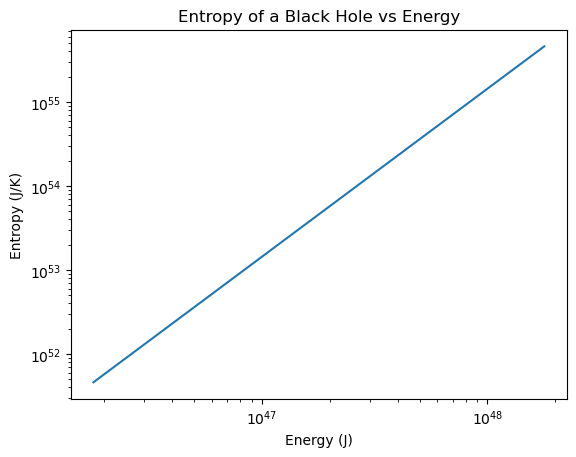

In [69]:
T_bh = (const.hbar*const.c**3/(6*1*u.M_sun*const.G*const.k_B)).to(u.K)

def entropy_black_hole(energy):
    """Calculate the entropy of a black hole given its energy."""
    # For a Schwarzschild black hole, the mass M is related to energy E by E = M * c^2
    M = energy / const.c**2
    return SBH(M)

energylinspace = np.linspace(0.1, 10, 100) * u.M_sun * const.c**2
energylinspace.to(u.J).value
plt.plot(energylinspace.to(u.J).value, [entropy_black_hole(E).to(u.Joule/u.K).value for E in energylinspace])
plt.xlabel('Energy (J)')
plt.ylabel('Entropy (J/K)')
plt.title('Entropy of a Black Hole vs Energy')
plt.xscale('log')
plt.yscale('log')

In [84]:

def C_to_K(C):
    return C + 273.15 * u.K

C_to_K(0)

(3.33*10**5 *(u.J/u.kg) * 0.030*u.kg )#/(273.15*u.K)

<Quantity 9990. J>

In [103]:
Q1=(3.33*10**5 *(u.J/u.kg) * 0.030*u.kg ) 
 
Q2= (4187 *(u.J/(u.kg*u.K)) * 0.030*u.kg * 25*u.K)

(Q1-Q2)/(298.15*u.K)

<Quantity 22.97417407 J / K>

In [104]:
36.57+11-22.97

24.6

In [ ]:
zx`x`